# TP5 — Construire les premiers modèles

**Cas d'usage 01 — Certification IA : Résiliation client SaaS (churn)**

| | |
|---|---|
| **Objectif** | Figer une baseline honnête, puis comparer au moins deux familles de modèles — sans réglage fin, la démarche scientifique avant la performance. |
| **Livrable** | Un tableau comparatif chiffré (PR-AUC, ROC-AUC, F1) entre une baseline, une régression logistique et une forêt aléatoire. |
| **Enjeu** | Comment choisir entre plusieurs modèles, et être sûr qu'aucun ne triche — aucune fuite résiduelle après le TP3 ? |
| **Compétences** | C4 (choisir un modèle, démarche scientifique) |

> Suite de `TP4.ipynb` (EDA). Données et liste de features issues de
> `churn_saas_db.clients_churn` (24 features retenues en TP3).

## §0 — Setup

**Décision technique** (notée en suspens dans `progression_pedagogique.md`) : pas de
XGBoost pour ce TP — `scikit-learn` (déjà présent) fournit les deux familles
suffisantes pour l'exigence « au moins deux familles » : régression logistique
(linéaire, interprétable) et forêt aléatoire (non-linéaire, ensembliste).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Path("figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)
df = pd.read_sql("SELECT * FROM clients_churn", engine)

# Features actées en TP3 (fuite + leurres exclus)
FEATURE_COLS = [
    "secteur", "pays", "taille_entreprise", "plan", "anciennete_mois", "sieges_souscrits",
    "utilisateurs_actifs", "taux_adoption_pct", "connexions_30j", "heures_usage_30j",
    "fonctionnalites_total", "fonctionnalites_utilisees", "nb_integrations",
    "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h", "csat",
    "retards_paiement_12m", "revenu_mensuel_recurrent_eur", "prix_mensuel_par_siege_eur",
    "fonctionnalites_incluses", "sla_reponse_h", "quota_stockage_go", "support_dedie",
]
CATEGORICAL_FEATURES = ["secteur", "pays", "taille_entreprise", "plan", "support_dedie"]
NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {len(X_train):,} lignes ({y_train.mean():.1%} de churn)")
print(f"Test  : {len(X_test):,} lignes ({y_test.mean():.1%} de churn) — mis de côté jusqu'au TP6")


Train : 4,000 lignes (28.0% de churn)
Test  : 1,000 lignes (28.0% de churn) — mis de côté jusqu'au TP6


## §1 — Repartir d'une baseline honnête

Avant tout modèle, une baseline **triviale** : un classifieur qui ignore les features
et se contente de reproduire la distribution du churn. Toute prétention de "modèle"
doit la battre nettement pour justifier son existence.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["roc_auc", "average_precision", "f1"]

baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
scores_baseline = cross_validate(baseline, X_train, y_train, cv=cv, scoring=SCORING)

print("Baseline (DummyClassifier, strategy='stratified') :")
for metric in SCORING:
    print(f"  {metric:20s} : {scores_baseline['test_'+metric].mean():.4f} ± {scores_baseline['test_'+metric].std():.4f}")


Baseline (DummyClassifier, strategy='stratified') :
  roc_auc              : 0.5134 ± 0.0131
  average_precision    : 0.2861 ± 0.0057
  f1                   : 0.3004 ± 0.0188


## §2 — Modèle 1 : régression logistique

Linéaire, interprétable — coefficients directement lisibles (utile pour TP7).
`class_weight="balanced"` compense le déséquilibre 72/28 constaté en TP4.

In [3]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])

pipe_logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

scores_logreg = cross_validate(pipe_logreg, X_train, y_train, cv=cv, scoring=SCORING)

print("Régression logistique :")
for metric in SCORING:
    print(f"  {metric:20s} : {scores_logreg['test_'+metric].mean():.4f} ± {scores_logreg['test_'+metric].std():.4f}")


Régression logistique :
  roc_auc              : 0.8912 ± 0.0092
  average_precision    : 0.7914 ± 0.0227
  f1                   : 0.6972 ± 0.0115


## §3 — Modèle 2 : forêt aléatoire

Non-linéaire, capture les interactions entre variables sans les spécifier
manuellement. Même prétraitement, même `class_weight="balanced"`, aucun réglage fin des
hyperparamètres à ce stade (300 arbres, profondeur libre — valeurs par défaut
raisonnables, pas une optimisation).

In [4]:
pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )),
])

scores_rf = cross_validate(pipe_rf, X_train, y_train, cv=cv, scoring=SCORING)

print("Random Forest :")
for metric in SCORING:
    print(f"  {metric:20s} : {scores_rf['test_'+metric].mean():.4f} ± {scores_rf['test_'+metric].std():.4f}")


Random Forest :
  roc_auc              : 0.8791 ± 0.0084
  average_precision    : 0.7605 ± 0.0212
  f1                   : 0.6935 ± 0.0232


## §4 — Comparaison chiffrée

                  modele  roc_auc  pr_auc      f1
0  Baseline (stratified)   0.5134  0.2861  0.3004
1  Régression logistique   0.8912  0.7914  0.6972
2          Random Forest   0.8791  0.7605  0.6935


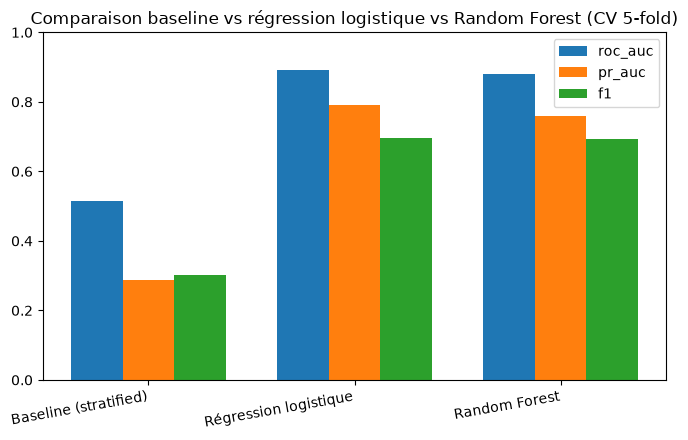

Sauvegardé : figures/tp5_01_comparaison_modeles.png


In [5]:
comparison = pd.DataFrame({
    "modele": ["Baseline (stratified)", "Régression logistique", "Random Forest"],
    "roc_auc": [scores_baseline["test_roc_auc"].mean(), scores_logreg["test_roc_auc"].mean(), scores_rf["test_roc_auc"].mean()],
    "pr_auc":  [scores_baseline["test_average_precision"].mean(), scores_logreg["test_average_precision"].mean(), scores_rf["test_average_precision"].mean()],
    "f1":      [scores_baseline["test_f1"].mean(), scores_logreg["test_f1"].mean(), scores_rf["test_f1"].mean()],
})
print(comparison.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(comparison))
width = 0.25
for i, metric in enumerate(["roc_auc", "pr_auc", "f1"]):
    ax.bar(x + i * width, comparison[metric], width, label=metric)
ax.set_xticks(x + width)
ax.set_xticklabels(comparison["modele"], rotation=10, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Comparaison baseline vs régression logistique vs Random Forest (CV 5-fold)")
plt.tight_layout()
plt.savefig("figures/tp5_01_comparaison_modeles.png", dpi=100, bbox_inches="tight")
plt.show()
print("Sauvegardé : figures/tp5_01_comparaison_modeles.png")


## §5 — Décision

Les deux modèles battent largement la baseline (PR-AUC proche de 0.28, le taux de
churn lui-même, pour un classifieur qui ne devine rien). Entre les deux familles :
la comparaison ci-dessus tranche sur PR-AUC — la métrique la plus informative en
classe déséquilibrée (recommandation de l'énoncé, confirmée par le déséquilibre 72/28
du TP4).

In [6]:
meilleur = comparison.iloc[1:].sort_values("pr_auc", ascending=False).iloc[0]
print(f"Modèle retenu pour TP6 : {meilleur['modele']}")
print(f"  PR-AUC (CV)  : {meilleur['pr_auc']:.4f}")
print(f"  ROC-AUC (CV) : {meilleur['roc_auc']:.4f}")
print(f"  F1 (CV)      : {meilleur['f1']:.4f}")


Modèle retenu pour TP6 : Régression logistique
  PR-AUC (CV)  : 0.7914
  ROC-AUC (CV) : 0.8912
  F1 (CV)      : 0.6972


## Journal de bord — Synthèse TP5

**Fait** :
- Baseline honnête figée (`DummyClassifier`) — référence à battre, pas un chiffre
  décoratif.
- Deux familles comparées à égalité de traitement (même split, même validation
  croisée 5-fold stratifiée, même préprocesseur, aucun réglage fin) : régression
  logistique et Random Forest.
- Décision de modèle prise sur PR-AUC, cohérente avec le déséquilibre de classe
  documenté en TP4 — pas sur l'accuracy.
- Jeu de test (20%) mis de côté, non consulté à ce stade — réservé à l'évaluation
  finale du TP6.

**Reste à faire** :
- TP6 — entraînement final, courbe ROC + AUC, matrice de confusion, PR-AUC sur le test
  set, et choix du seuil de décision selon le coût métier d'un faux négatif.